In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load Data NO2 Station Raw
no2_station_raw = pd.read_excel(r"D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\CSV\no2_station.xlsx")

# Set Index Datetime
no2_station_raw['date'] = pd.to_datetime(no2_station_raw['date'])
no2_station_raw.set_index('date', inplace=True)
no2_station_raw.head()


,no2_station
date,
2025-01-01 00:00:00,NaN
2025-01-01 00:30:00,NaN
2025-01-01 01:00:00,NaN
2025-01-01 01:30:00,NaN
2025-01-01 02:00:00,NaN


no2_station    3050
dtype: int64


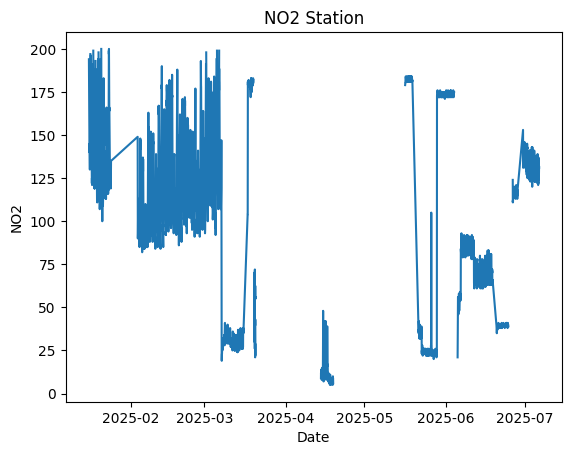

In [4]:
# Plot Data
df = no2_station_raw.copy()

# Check NaN Values
print(df.isna().sum())

x=df.index
y=df['no2_station']

plt.plot(x,y, label='NO2 Station')
plt.title('NO2 Station')
plt.xlabel('Date')
plt.ylabel('NO2')
plt.show()

                     no2_station
date                            
2025-01-01 07:00:00          NaN
2025-01-01 07:30:00          NaN
2025-01-01 08:00:00          NaN
2025-01-01 08:30:00          NaN
2025-01-01 09:00:00          NaN


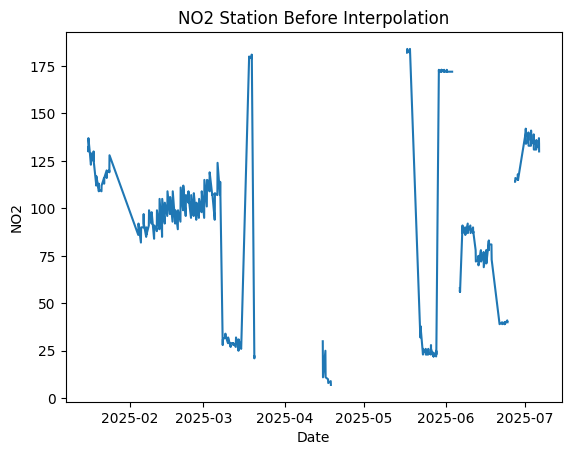

In [5]:
# Filter Data 07 - 09
df_filtered = df[(df.index.hour >= 7) & (df.index.hour <= 9) & ~((df.index.hour == 9) & (df.index.minute == 30))]
df_filtered = df_filtered.reset_index()
df_filtered['date'] = pd.to_datetime(df_filtered['date'])
df_filtered.set_index('date', inplace=True)

print(df_filtered.head())

# Plot Data Filter 
x=df_filtered.index
y=df_filtered['no2_station']

plt.plot(x,y, label='NO2 Station Before Interpolation')
plt.title('NO2 Station Before Interpolation')
plt.xlabel('Date')
plt.ylabel('NO2')
plt.show()

In [6]:
# Masking untuk bulan Januari
mask_january = df_filtered.index.month == 1
mean_january = df_filtered[mask_january]['no2_station'].mean()

start_time_jan = '2025-01-01 07:00:00'
end_time_jan = '2025-01-01 07:30:00'

mask_jan = (df_filtered.index >= start_time_jan) & (df_filtered.index <= end_time_jan)
df_filtered.loc[mask_jan, 'no2_station'] = mean_january


# Masking April
mask_april = df_filtered.index.month == 4
mean_april = df_filtered[mask_april]['no2_station'].mean()

# Rentang waktu pertama
start_time_apr_0 = '2025-04-01 07:00:00'
end_time_apr_0 = '2025-04-01 07:30:00'
mask_apr_start = (df_filtered.index >= start_time_apr_0) & (df_filtered.index <= end_time_apr_0)

# Rentang waktu kedua
start_time_apr_1 = '2025-04-30 08:30:00'
end_time_apr_1 = '2025-04-30 09:00:00'
mask_apr_end = (df_filtered.index >= start_time_apr_1) & (df_filtered.index <= end_time_apr_1)

# Mengisi nilai NaN dengan rata-rata bulan April pada dua rentang waktu yang terpisah
df_filtered.loc[mask_apr_start, 'no2_station'] = df_filtered.loc[mask_apr_start, 'no2_station'].fillna(mean_april)
df_filtered.loc[mask_apr_end, 'no2_station'] = df_filtered.loc[mask_apr_end, 'no2_station'].fillna(mean_april)

# Masking May
mask_may = df_filtered.index.month == 5
mean_may = df_filtered[mask_may]['no2_station'].mean()

start_time_may = '2025-05-01 07:00:00'
end_time_may = '2025-05-01 07:30:00'

mask_may = (df_filtered.index >= start_time_may) & (df_filtered.index <= end_time_may)
df_filtered.loc[mask_may, 'no2_station'] = mean_may

# Masking Mar
mask_mar = df_filtered.index.month == 5
mean_mar = df_filtered[mask_mar]['no2_station'].mean()

start_time_mar = '2025-03-31 08:30:00'
end_time_mar = '2025-03-31 09:00:00'

mask_mar = (df_filtered.index >= start_time_mar) & (df_filtered.index <= end_time_mar)
df_filtered.loc[mask_mar, 'no2_station'] = mean_mar

# Menampilkan data setelah pengisian
df_filtered.head(10)

,no2_station
date,
2025-01-01 07:00:00,119.466667
2025-01-01 07:30:00,119.466667
2025-01-01 08:00:00,NaN
2025-01-01 08:30:00,NaN
2025-01-01 09:00:00,NaN
2025-01-02 07:00:00,NaN
2025-01-02 07:30:00,NaN
2025-01-02 08:00:00,NaN
2025-01-02 08:30:00,NaN


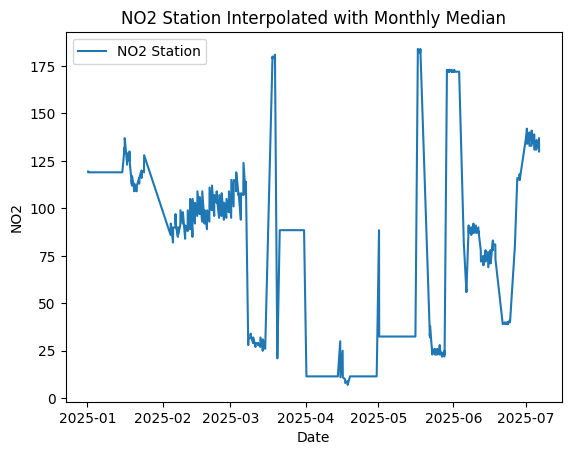

In [7]:
# Median per Part
# Mask Januari
mask_january = (df_filtered.index.month == 1)

# Mask Maret
mask_march = (df_filtered.index.month == 3)

# Mask April
mask_april = (df_filtered.index.month == 4)

# Mask May
mask_may = (df_filtered.index.month == 5)

# Mask June
mask_june = (df_filtered.index.month == 6)

# Median NaN Month Values
median_january = df_filtered[mask_january]['no2_station'].median()
median_march = df_filtered[mask_march]['no2_station'].median()
median_april = df_filtered[mask_april]['no2_station'].median()
median_may = df_filtered[mask_may]['no2_station'].median()
median_june = df_filtered[mask_june]['no2_station'].median()

# Filling NaN
df_filtered.loc[mask_january, 'no2_station'] = df_filtered.loc[mask_january, 'no2_station'].fillna(median_january)
df_filtered.loc[mask_march, 'no2_station'] = df_filtered.loc[mask_march, 'no2_station'].fillna(median_march)
df_filtered.loc[mask_april, 'no2_station'] = df_filtered.loc[mask_april, 'no2_station'].fillna(median_april)
df_filtered.loc[mask_may, 'no2_station'] = df_filtered.loc[mask_may, 'no2_station'].fillna(median_may)
df_filtered.loc[mask_june, 'no2_station'] = df_filtered.loc[mask_june, 'no2_station'].fillna(median_june)

# Plot
x_raw = df_filtered.index
y_raw = df_filtered['no2_station']

plt.plot(x, y, label='NO2 Station')
plt.title('NO2 Station Interpolated with Monthly Median')
plt.xlabel('Date')
plt.ylabel('NO2')
plt.legend()
plt.show()

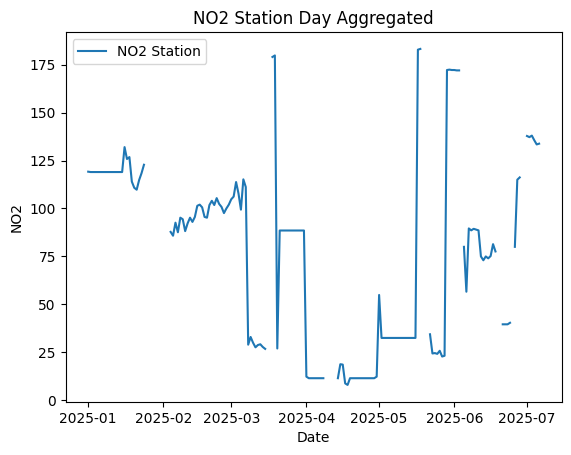

In [8]:
# Day Aggregation
df_daily = df_filtered.resample('D').mean()

# Plot
x_daily = df_daily.index
y_daily = df_daily['no2_station']

plt.plot(x_daily, y_daily, label='NO2 Station')
plt.title('NO2 Station Day Aggregated')
plt.xlabel('Date')
plt.ylabel('NO2')
plt.legend()
plt.show()

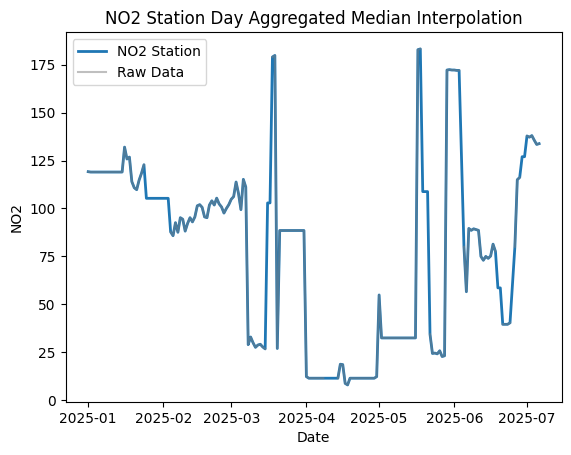

In [9]:
# Median Interpolate Day Aggregation
df_interpolation = df_daily.copy()

# Mask
mask_1_start = '2025-01-24'
mask_1_end = '2025-02-04'

mask_2_start = '2025-03-15'
mask_2_end = '2025-03-18'

mask_3_start = '2025-04-08'
mask_3_end = '2025-04-11'

mask_4_start = '2025-04-11'
mask_4_end = '2025-04-14'

mask_5_start = '2025-05-18'
mask_5_end = '2025-05-22'

mask_6_start = '2025-06-03'
mask_6_end = '2025-06-05'

mask_7_start = '2025-06-18'
mask_7_end = '2025-06-21'

mask_8_start = '2025-06-24'
mask_8_end = '2025-06-26'

mask_9_start = '2025-06-28'
mask_9_end = '2025-07-01'

# Filter data berdasarkan tanggal
mask_1 = (df_interpolation.index >= mask_1_start) & (df_interpolation.index <= mask_1_end)
mask_2 = (df_interpolation.index >= mask_2_start) & (df_interpolation.index <= mask_2_end)
mask_3 = (df_interpolation.index >= mask_3_start) & (df_interpolation.index <= mask_3_end)
mask_4 = (df_interpolation.index >= mask_4_start) & (df_interpolation.index <= mask_4_end)
mask_5 = (df_interpolation.index >= mask_5_start) & (df_interpolation.index <= mask_5_end)
mask_6 = (df_interpolation.index >= mask_6_start) & (df_interpolation.index <= mask_6_end)
mask_7 = (df_interpolation.index >= mask_7_start) & (df_interpolation.index <= mask_7_end)
mask_8 = (df_interpolation.index >= mask_8_start) & (df_interpolation.index <= mask_8_end)
mask_9 = (df_interpolation.index >= mask_9_start) & (df_interpolation.index <= mask_9_end)


# Median untuk nilai NaN
median_mask1 = df_interpolation.loc[mask_1, 'no2_station'].median()
median_mask2 = df_interpolation.loc[mask_2, 'no2_station'].median()
median_mask3 = df_interpolation.loc[mask_3, 'no2_station'].median()
median_mask4 = df_interpolation.loc[mask_4, 'no2_station'].median()
median_mask5 = df_interpolation.loc[mask_5, 'no2_station'].median()
median_mask6 = df_interpolation.loc[mask_6, 'no2_station'].median()
median_mask7 = df_interpolation.loc[mask_7, 'no2_station'].median()
median_mask8 = df_interpolation.loc[mask_8, 'no2_station'].median()
median_mask9 = df_interpolation.loc[mask_9, 'no2_station'].median()

# Mengisi NaN
df_interpolation.loc[mask_1, 'no2_station'] = df_interpolation.loc[mask_1, 'no2_station'].fillna(median_mask1)
df_interpolation.loc[mask_2, 'no2_station'] = df_interpolation.loc[mask_2, 'no2_station'].fillna(median_mask2)
df_interpolation.loc[mask_3, 'no2_station'] = df_interpolation.loc[mask_3, 'no2_station'].fillna(median_mask3)
df_interpolation.loc[mask_4, 'no2_station'] = df_interpolation.loc[mask_4, 'no2_station'].fillna(median_mask4)
df_interpolation.loc[mask_5, 'no2_station'] = df_interpolation.loc[mask_5, 'no2_station'].fillna(median_mask5)
df_interpolation.loc[mask_6, 'no2_station'] = df_interpolation.loc[mask_6, 'no2_station'].fillna(median_mask6)
df_interpolation.loc[mask_7, 'no2_station'] = df_interpolation.loc[mask_7, 'no2_station'].fillna(median_mask7)
df_interpolation.loc[mask_8, 'no2_station'] = df_interpolation.loc[mask_8, 'no2_station'].fillna(median_mask8)
df_interpolation.loc[mask_9, 'no2_station'] = df_interpolation.loc[mask_9, 'no2_station'].fillna(median_mask9)

# Plot hasil
x_daily_inter = df_interpolation.index
y_daily_inter = df_interpolation['no2_station']

plt.plot(x_daily_inter, y_daily_inter, label='NO2 Station', linewidth=2)
plt.plot(x_daily, y_daily, label='Raw Data', color='gray', alpha=0.5)
plt.title('NO2 Station Day Aggregated Median Interpolation')
plt.xlabel('Date')
plt.ylabel('NO2')
plt.legend()
plt.show()

In [10]:
print(len(df_interpolation['no2_station']))

187


C:\Users\nuryabilla utami\AppData\Local\Temp\ipykernel_28376\1618657775.py:18: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  D = diags([1, -2, 1], [0, 1, 2], shape=(n - d, n)).toarray()


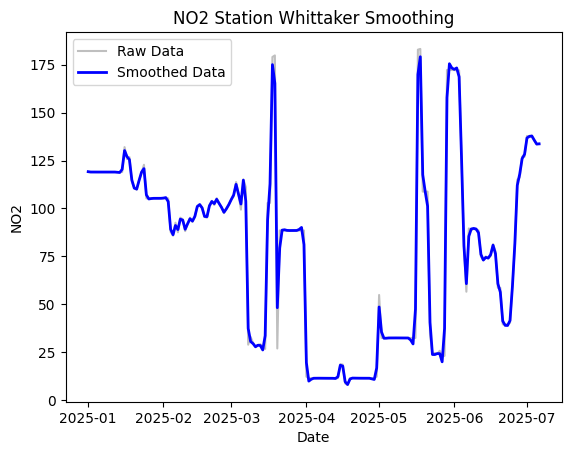

In [11]:
from scipy.linalg import inv
from scipy.sparse import diags # Import diags for constructing the penalty matrix D

# Fungsi untuk melakukan smoothing Whittaker
def whittaker_smoothing(y, lam, d=2):
    """
    Fungsi untuk melakukan smoothing Whittaker
    :param y: Data asli (pandas Series or numpy array)
    :param lam: Parameter smoothing
    :param d: Derivatif (biasanya 2 untuk smoothing kedua)
    :return: Data yang dihaluskan (numpy array)
    """
    n = len(y)

    # Construct the penalty matrix D with shape (n-d, n)
    # For d=2, the difference operator coefficients are [1, -2, 1]
    # These coefficients are for diagonals at offsets 0, 1, 2.
    D = diags([1, -2, 1], [0, 1, 2], shape=(n - d, n)).toarray()

    # Calculate the penalty term W
    W = lam * D.T @ D

    # Identity matrix.
    I = np.eye(n)

    # Solusi Whittaker (smoothing): (I + W) @ f = y
    # Ensure y is a numpy array for matrix multiplication
    f = np.linalg.inv(I + W) @ y.to_numpy()

    return f

# Variabel
x = df_interpolation.index
y = df_interpolation['no2_station']

# Whittaker Smoothing
lambda_param = 0.05  # Parameter
smoothed_no2 = whittaker_smoothing(y, lambda_param)

# Plot
plt.plot(x_daily_inter, y_daily_inter, label='Raw Data', color='gray', alpha=0.5)
plt.plot(x, smoothed_no2, label='Smoothed Data', color='blue', linewidth=2)
plt.legend()
plt.title('NO2 Station Whittaker Smoothing')
plt.xlabel('Date')
plt.ylabel('NO2')
plt.show()

In [13]:
# Merge Result
df_interpolated_smoothed = df_interpolation.copy()
df_interpolated_smoothed['no2_station_smooth'] = smoothed_no2
df_interpolated_smoothed.head()

,no2_station,no2_station_smooth
date,,
2025-01-01,119.186667,119.179311
2025-01-02,119.000000,119.013596
2025-01-03,119.000000,118.994996
2025-01-04,119.000000,118.998705
2025-01-05,119.000000,119.000001


# **Evaluasi Model Smoothing**

In [14]:
np.corrcoef(y, smoothed_no2)[0,1]

print(f'Koefisien Korelasi antara Data Asli dan Smoothed: {np.corrcoef(y, smoothed_no2)[0,1]:.4f}')
print(f'Varians Data Asli: {np.var(y):.4f}')
print(f'Varians Data Smoothed: {np.var(smoothed_no2):.4f}')

Koefisien Korelasi antara Data Asli dan Smoothed: 0.9971
Varians Data Asli: 2183.1576
Varians Data Smoothed: 2101.0832


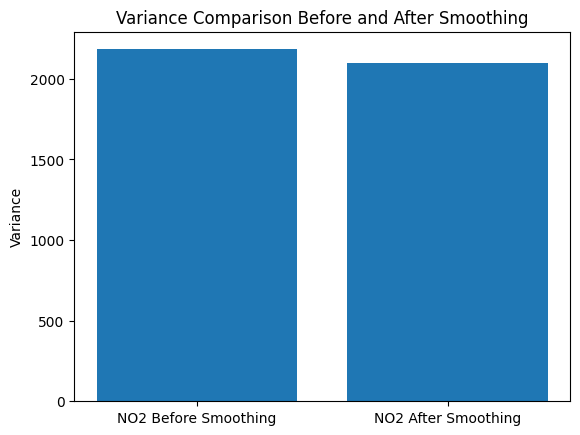

In [15]:
import numpy as np

var_asli = np.var(y)
var_smooth = np.var(smoothed_no2)

plt.figure()
plt.bar(['NO2 Before Smoothing', 'NO2 After Smoothing'], [var_asli, var_smooth])

plt.title('Variance Comparison Before and After Smoothing')
plt.ylabel('Variance')
plt.show()

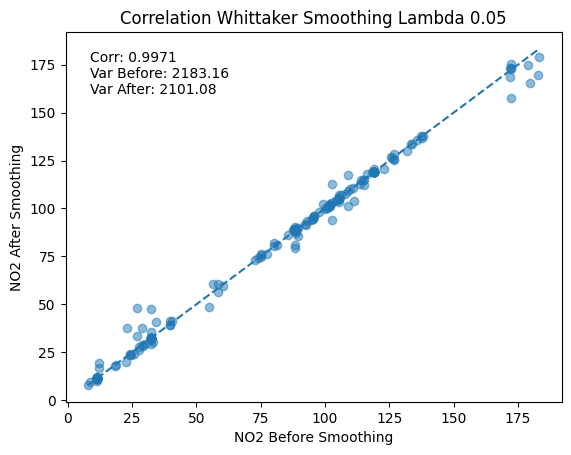

In [17]:
corr = np.corrcoef(y, smoothed_no2)[0,1]

plt.figure()
plt.scatter(y, smoothed_no2, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], linestyle='--')

plt.title(f'Correlation Whittaker Smoothing Lambda 0.05')
plt.xlabel('NO2 Before Smoothing')
plt.ylabel('NO2 After Smoothing')

plt.text(0.05, 0.95,
         f'Corr: {corr:.4f}\nVar Before: {var_asli:.2f}\nVar After: {var_smooth:.2f}',
         transform=plt.gca().transAxes,
         verticalalignment='top')

plt.show()

C:\Users\nuryabilla utami\AppData\Local\Temp\ipykernel_28376\1618657775.py:18: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  D = diags([1, -2, 1], [0, 1, 2], shape=(n - d, n)).toarray()


Text(0.5, 0, 'Date')

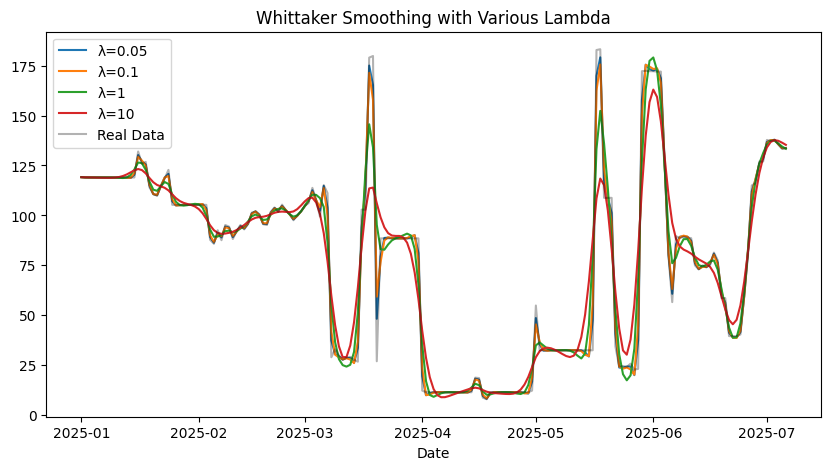

In [18]:
lam_list = [0.05, 0.1, 1, 10]

plt.figure(figsize=(10,5))

for lam in lam_list:
    smooth = whittaker_smoothing(y, lam)
    plt.plot(y.index, smooth, label=f'λ={lam}')

plt.plot(y.index, y, color='black', alpha=0.3, label='Real Data')

plt.legend()
plt.title('Whittaker Smoothing with Various Lambda')
plt.xlabel('Date')

In [ ]:
# Extract Values and time to Excel
import os

output_path = r'D:\Kuliah UNDIP\Semester 7\TA\PENGOLAHAN\github\output'
df_interpolated_smoothed.reset_index().to_excel(os.path.join(output_path, 'no2_station_interpolated_smoothed.xlsx'), index=False)